#### 𝗚𝗥𝗢𝗨𝗣 𝟱 - 𝗕𝗦𝗜𝗧-𝟮𝗔

Members: 
1. Domingo, Mario Jr. C.
2. Daclison, Trisha Jamaica U.
3. Dela Cruz, Bic Julian

#### **1. Background of the Study**

**Title:** Forecasting Population Growth Trends in the Philippines (2020–2025)

**Source:** Philippines Population Projection Dataset (2020–2025), Admin3 / PSA (psa.gov.ph)

---

**Brief Description of Dataset**
- **Size:** 1,635 rows × 12 columns  
- **Unit of analysis:** One row = one city/municipality  
- **Time coverage:** July 2020 to July 2025 (midyear population, levels)

**Main Columns**
- `Region` — Administrative region name  
- `Region_pcode` — Region code  
- `Province` — Province name  
- `Province_pcode` — Province code  
- `Municipality_City` — City/Municipality name  
- `Mun_pcode` — City/Municipality code  
- `July2020` … `July2025` — Projected midyear population (levels)

> The dataset provides municipal/city population projections based on the 2015 Census and PSA growth-rate estimates.

---

**Selected Features (Independent Variables)**
- Year (2020 - 2025), Region, Province, Municipality/City

**Target / Label (Dependent Variable)**
- Population — projected population for each city/municipality in a given year (values from July2020 to July2025)

---

**Objectives**
We aim to build a regression model that analyzes and predicts population growth trends for Philippine cities and municipalities.

1. **Estimate the annual growth rate** for each locality (year-to-year change).  
2. **Identify the fastest and slowest growing** regions/provinces/municipalities.  
3. **Forecast beyond 2025** (e.g., to 2030) using the learned time trend.

#### **2. Data Collection/Loading**

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Excel sheet into a DataFrame
df = pd.read_excel("Philippines Population Projection dataset (2020–2025).xlsx")

# Display the first 10 rows
df.head(10)


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702
5,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Burgos,PH012806000,9948,9970,9987,10000,10009,10013
6,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Carasi,PH012807000,1644,1658,1672,1684,1696,1708
7,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Currimao,PH012808000,12419,12451,12477,12498,12513,12523
8,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dingras,PH012809000,39673,39850,40009,40152,40277,40386
9,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dumalneg,PH012810000,3267,3332,3397,3461,3525,3589


#### **3. Data Information and Summary Statistics**


In [23]:
# Check the Structure of the Data (Columns, Data Types and Non-Null Counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Region             1634 non-null   object
 1   Region_pcode       1634 non-null   object
 2   Province           1634 non-null   object
 3   Province_pcode     1634 non-null   object
 4   Municipality_City  1634 non-null   object
 5   Mun_Pcode          1634 non-null   object
 6   July2020           1634 non-null   int64 
 7   July2021           1634 non-null   int64 
 8   July2022           1634 non-null   int64 
 9   July2023           1634 non-null   int64 
 10  July2024           1634 non-null   int64 
 11  July2025           1634 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 153.3+ KB


In [24]:
# Check for Missing or Invalid Values
df.isnull().sum()# Check for Missing or Invalid Values
df.isnull().sum()

Region               0
Region_pcode         0
Province             0
Province_pcode       0
Municipality_City    0
Mun_Pcode            0
July2020             0
July2021             0
July2022             0
July2023             0
July2024             0
July2025             0
dtype: int64

In [25]:
# Format numerical outputs to display full numbers with commas instead of scientific notations 
pd.set_option('display.float_format', '{:,.0f}'.format)

# Get Summary Statistics for Numeric Columns
df.describe()

,July2020,July2021,July2022,July2023,July2024,July2025
count,"1,634","1,634","1,634","1,634","1,634","1,634"
mean,"66,568","67,441","68,282","69,090","69,868","70,611"
std,"140,116","141,956","143,725","145,423","147,057","148,618"
min,193,194,195,196,196,196
25%,"22,758","22,860","23,097","23,250","23,322","23,520"
50%,"36,255","36,718","36,960","37,394","37,706","38,006"
75%,"65,011","65,496","66,090","66,530","67,042","67,646"
max,"3,080,813","3,102,433","3,121,477","3,137,962","3,151,858","3,163,105"


In [26]:
# Import display function to show DataFrames neatly (Formatted Output)
from IPython.display import display

# Reshape data into long format for easier analysis
df_melted = df.melt (
    id_vars = ['Region', 'Region_pcode', 'Province', 'Province_pcode', 'Municipality_City', 'Mun_Pcode'],
    var_name = 'Year',
    value_name = 'Population'
)

# Display the first few rows of the reshaped data
display(df_melted.head())

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,Year,Population
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,July2020,1823
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,July2020,32778
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,July2020,32218
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,July2020,14954
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,July2020,56248


#### **4. Data Cleaning**

In [27]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [28]:
# Verify no negative and unrealistic population values
(df[['July2020', 'July2021', 'July2022', 'July2023', 'July2024', 'July2025']] < 0).sum()

July2020    0
July2021    0
July2022    0
July2023    0
July2024    0
July2025    0
dtype: int64

In [29]:
# Clean text data by removing leading/trailing spaces
df['Region'] = df['Region'].str.strip()
df['Province'] = df['Province'].str.strip()
df['Municipality_City'] = df['Municipality_City'].str.strip()

# Display first 10 rows confirm text fields look clean and consistent
display(df[['Region', 'Province', 'Municipality_City']].head(10))

# Check if there are still rows with leading/trailing spaces after cleaning
df[
    (df['Region'] != df['Region'].str.strip()) |
    (df['Province'] != df['Province'].str.strip()) |
    (df['Municipality_City'] != df['Municipality_City'].str.strip())
]

# Output will be an empty table meaning all spaces were successfully removed

,Region,Province,Municipality_City
0,Region I (Ilocos Region),Ilocos Norte,Adams
1,Region I (Ilocos Region),Ilocos Norte,Bacarra
2,Region I (Ilocos Region),Ilocos Norte,Badoc
3,Region I (Ilocos Region),Ilocos Norte,Bangui
4,Region I (Ilocos Region),Ilocos Norte,City of Batac
5,Region I (Ilocos Region),Ilocos Norte,Burgos
6,Region I (Ilocos Region),Ilocos Norte,Carasi
7,Region I (Ilocos Region),Ilocos Norte,Currimao
8,Region I (Ilocos Region),Ilocos Norte,Dingras
9,Region I (Ilocos Region),Ilocos Norte,Dumalneg


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025


In [30]:
# Recheck and Drop Duplicates (For Safety)
df.drop_duplicates(inplace=True)

df.head()

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702


#### **5. Data Engineering / Pre-Processing**

In [31]:
# Import LabelEncoder to convert text labels (words) into numeric codes t be usead in machine learning or statistical analysis
from sklearn.preprocessing import LabelEncoder

# Create separate encoders for each categorical column
region_encoder = LabelEncoder()
province_encoder = LabelEncoder()
city_encoder = LabelEncoder()

# Fit and transform each column independently
df['Region_Code'] = region_encoder.fit_transform(df['Region'])
df['Province_Code'] = province_encoder.fit_transform(df['Province'])
df['City_Code'] = city_encoder.fit_transform(df['Municipality_City'])

# Display a sample of encoded data (first 10 rows)
display(df[['Region', 'Region_Code', 'Province', 'Province_Code', 'Municipality_City', 'City_Code']].head(10))


,Region,Region_Code,Province,Province_Code,Municipality_City,City_Code
0,Region I (Ilocos Region),3,Ilocos Norte,37,Adams,6
1,Region I (Ilocos Region),3,Ilocos Norte,37,Bacarra,84
2,Region I (Ilocos Region),3,Ilocos Norte,37,Badoc,97
3,Region I (Ilocos Region),3,Ilocos Norte,37,Bangui,140
4,Region I (Ilocos Region),3,Ilocos Norte,37,City of Batac,333
5,Region I (Ilocos Region),3,Ilocos Norte,37,Burgos,238
6,Region I (Ilocos Region),3,Ilocos Norte,37,Carasi,302
7,Region I (Ilocos Region),3,Ilocos Norte,37,Currimao,429
8,Region I (Ilocos Region),3,Ilocos Norte,37,Dingras,479
9,Region I (Ilocos Region),3,Ilocos Norte,37,Dumalneg,496


In [32]:
# Show all unique regions with their assigned numeric codes
unique_regions = df[['Region', 'Region_Code']].drop_duplicates().sort_values('Region_Code')

# Display the mapping of regions to codes
display(unique_regions)

,Region,Region_Code
1370,Autonomous Region in Muslim Mindanao (ARMM),0
1293,Cordillera Administrative Region (CAR),1
1276,National Capital Region (NCR),2
0,Region I (Ilocos Region),3
125,Region II (Cagayan Valley),4
218,Region III (Central Luzon),5
348,Region IV-A (CALABARZON),6
1561,Region IV-B (MIMAROPA),7
1012,Region IX (Zamboanga Peninsula),8
490,Region V (Bicol Region),9


In [33]:
# Display the first 10 rows to verify that categorical columns were correctly encoded into numeric codes
display(df[['Region', 'Region_Code', 'Province', 'Province_Code', 'Municipality_City', 'City_Code']].head(10))

,Region,Region_Code,Province,Province_Code,Municipality_City,City_Code
0,Region I (Ilocos Region),3,Ilocos Norte,37,Adams,6
1,Region I (Ilocos Region),3,Ilocos Norte,37,Bacarra,84
2,Region I (Ilocos Region),3,Ilocos Norte,37,Badoc,97
3,Region I (Ilocos Region),3,Ilocos Norte,37,Bangui,140
4,Region I (Ilocos Region),3,Ilocos Norte,37,City of Batac,333
5,Region I (Ilocos Region),3,Ilocos Norte,37,Burgos,238
6,Region I (Ilocos Region),3,Ilocos Norte,37,Carasi,302
7,Region I (Ilocos Region),3,Ilocos Norte,37,Currimao,429
8,Region I (Ilocos Region),3,Ilocos Norte,37,Dingras,479
9,Region I (Ilocos Region),3,Ilocos Norte,37,Dumalneg,496


In [34]:
# Import the StandardScaler to normalize numeric data
from sklearn.preprocessing import StandardScaler

# Standardize numeric population columns for balanced scaling
# (This converts all values into a common scale with mean = 0 and standard deviation = 1)
scaler = StandardScaler()

# Apply scaling to all population columns
df[['July2020', 'July2021', 'July2022', 'July2023', 'July2024', 'July2025']] = scaler.fit_transform(
    df[['July2020', 'July2021', 'July2022', 'July2023', 'July2024', 'July2025']]
)

# Display first few rows after scaling to confirm transformation
# (Values are now standardized — they may include decimals and negative numbers)
display(df.head())


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025,Region_Code,Province_Code,City_Code
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,-0,-0,-0,-0,-0,-0,3,37,6
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,-0,-0,-0,-0,-0,-0,3,37,84
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,-0,-0,-0,-0,-0,-0,3,37,97
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,-0,-0,-0,-0,-0,-0,3,37,140
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,-0,-0,-0,-0,-0,-0,3,37,333


In [35]:
# (Optional) Check summary statistics to verify mean ≈ 0 and std ≈ 1
df.describe()

,July2020,July2021,July2022,July2023,July2024,July2025,Region_Code,Province_Code,City_Code
count,"1,634","1,634","1,634","1,634","1,634","1,634","1,634","1,634","1,634"
mean,-0,0,0,0,0,-0,8,44,740
std,1,1,1,1,1,1,5,24,416
min,-0,-0,-0,-0,-0,-0,0,0,0
25%,-0,-0,-0,-0,-0,-0,4,22,377
50%,-0,-0,-0,-0,-0,-0,8,44,758
75%,-0,-0,-0,-0,-0,-0,11,65,"1,120"
max,22,21,21,21,21,21,16,86,"1,436"


#### **6. Data Visualization**

In [ ]:
# Make a copy so we don't accidentally change the original.
data = df.copy()

# Select the population columns only (those named like 'JulyYYYY')
pop_cols = [c for c in data.columns if c.startswith("July")]

# Make sure the expected year columns exist.
assert set(["July2020","July2021","July2022","July2023","July2024","July2025"]).issubset(pop_cols), \
    "Expected year columns July2020–July2025 not found."

# Plot formatting
plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-6, 6)


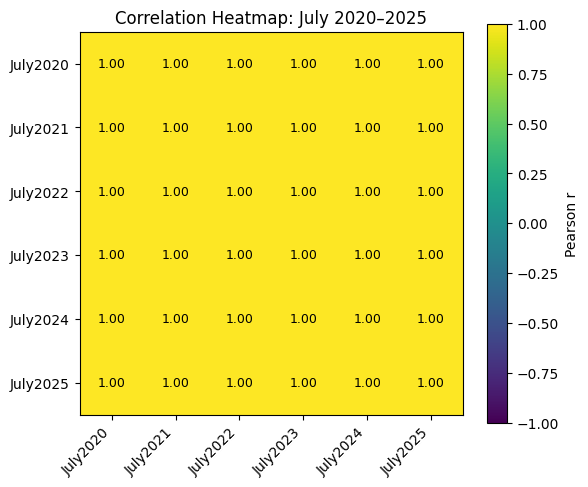

In [ ]:
# 6.1 Correlation heatmap (2020–2025)

# Compute the correlation matrix (Pearson r) for the year columns
corr = data[pop_cols].corr(method="pearson")

# Set up the figure and axis for plotting
fig, ax = plt.subplots(figsize=(6, 5))

# Draw the heatmap (values mapped to colors from -1 to +1)
im = ax.imshow(corr.values, vmin=-1, vmax=1)

# Put tick marks for each year on both axes
ax.set_xticks(range(len(pop_cols)))
ax.set_yticks(range(len(pop_cols)))

# Label the ticks with the column names (rotate x-labels for readability)
ax.set_xticklabels(pop_cols, rotation=45, ha="right")
ax.set_yticklabels(pop_cols)

# Write the numeric correlation (e.g., 0.97) inside each cell
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

# Add a color bar to explain the scale of colors
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson r")

# Title + layout + render the plot
ax.set_title("Correlation Heatmap: July 2020–2025")
plt.tight_layout()
plt.show()



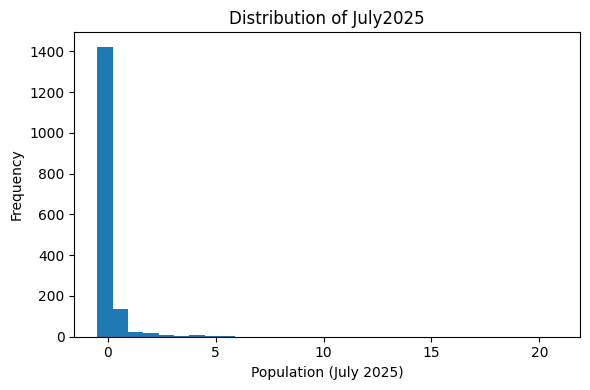

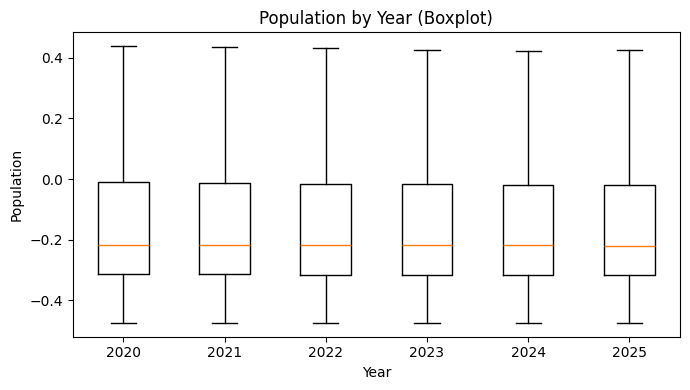

In [45]:
# 6.2 Distribution of the target (July2025): histogram + (optional) boxplot

# Histogram of July2025
# Set up a figure and axis for the histogram
fig, ax = plt.subplots(figsize=(6,4))

# Draw the histogram of July2025 (30 bins shows shape clearly)
ax.hist(data["July2025"].values, bins=30)

# Label the axes for clear interpretation
ax.set_xlabel("Population (July 2025)")
ax.set_ylabel("Frequency")

# Add a concise, descriptive title 
ax.set_title("Distribution of July2025")

# Tighten layout and render the plot
plt.tight_layout()
plt.show()


# Boxplot across years (2020–2025) to compare distributions
# Set up a figure and axis for the boxplot
fig, ax = plt.subplots(figsize=(7,4))

# Prepare year-wise values and readable tick labels
year_values = [data[c].values for c in pop_cols]
year_labels = [c.replace("July","") for c in pop_cols]

# Draw the boxplot to compare distributions across years
ax.boxplot(year_values, tick_labels=year_labels, showfliers=False)

# Label the axes for context
ax.set_xlabel("Year")
ax.set_ylabel("Population")

# Add a concise, descriptive title
ax.set_title("Population by Year (Boxplot)")

# Tighten layout and render the plot
plt.tight_layout()
plt.show()



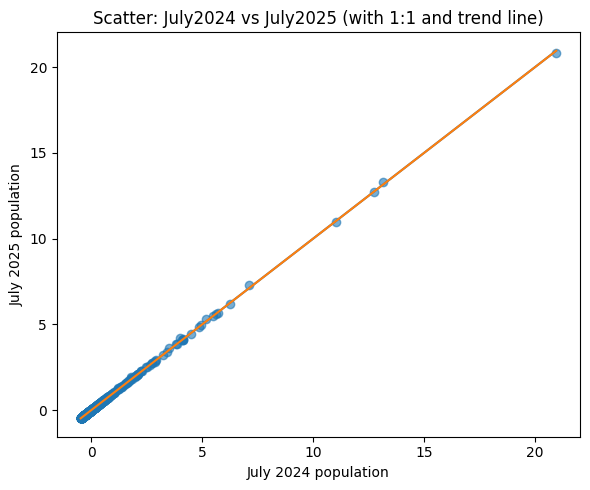

In [46]:
# 6.3 Scatter plot for regression signal (July2024 → July2025)

# Extract x (2024) and y (2025) as arrays
x = data["July2024"].values
y = data["July2025"].values

# Create the figure and axis for the scatter plot
fig, ax = plt.subplots(figsize=(6,5))

# Plot the points (alpha adds slight transparency for overlap)
ax.scatter(x, y, alpha=0.6)

# Draw the 1:1 reference line to compare “no change” vs actual
mn, mx = min(x.min(), y.min()), max(x.max(), y.max())
ax.plot([mn, mx], [mn, mx])

# Fit and draw the least-squares trend line (y = m*x + b)
m, b = np.polyfit(x, y, 1)
ax.plot([mn, mx], [m*mn + b, m*mx + b])

# Label axes, add title, tidy layout, and render
ax.set_xlabel("July 2024 population")
ax.set_ylabel("July 2025 population")
ax.set_title("Scatter: July2024 vs July2025 (with 1:1 and trend line)")
plt.tight_layout()
plt.show()


#### **7. Data Splitting (Training and Testing Set)**